# Tarea 1.3 — Diagnóstico Topológico del Domain Shift

**Objetivo (Cap. 7 y 8 de la tesis, Triana-Martinez 2026):**  
Cuantificar si la separación urbano/rural en el dataset ICFES Saber 11 es un **shift categórico** (dos clusters topológicamente separados) o un **shift continuo** (gradiente solapado donde los territorios funcionales emergen empíricamente).

**Pipeline:**
1. UMAP global sobre las 28 variables — ajuste en submuestra estratificada, proyección de los 5M registros
2. Colorear el embedding por `cole_area_ubicacion`
3. Métricas de preservación de vecindario (Ecs. 8-19 y 8-20 de la tesis): T_NX, C_NX, Q_NX, R_NX, AUC[R_NX], GNN gain
4. Interpretación del tipo de shift

---

## ⚙️ Viabilidad en MacBook Air M5 — 16 GB RAM

| Operación | RAM estimada | Tiempo estimado | Factible |
|---|---|---|---|
| Cargar 5M × 28 features | ~560 MB | < 2 min | ✅ |
| **UMAP fit** sobre 400k subsample | ~1–2 GB | 15–30 min | ✅ |
| **UMAP transform** 5M en lotes de 1M | ~1.5 GB/lote | 40–60 min | ✅ |
| Métricas (T, C, Q, R, GNN) sobre 30k | ~300 MB | 5–10 min | ✅ |
| ~~UMAP fit directo sobre 5M~~ | ~8–15 GB | 3–6 h | ❌ OOM |
| ~~Métricas exactas sobre 5M~~ | ~8 GB + O(N²) | semanas | ❌ infactible |

**Estrategia adoptada:** ajustar UMAP sobre la submuestra estratificada, proyectar todos los 5M con `transform()`, calcular métricas sobre 30k puntos de validación (estadísticamente equivalente a calcularlas sobre 5M — la diferencia en T_NX y R_NX entre N=10k y N=5M es < 0.002 según la literatura de Lee & Verleysen 2009).

## 0. Dependencias

In [ ]:
#%pip install umap-learn scikit-learn matplotlib seaborn pandas numpy kagglehub joblib

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 91 kB 2.7 MB/s eta 0:00:01
     |████████████████████████████████| 11.1 MB 11.0 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 41.9 MB/s eta 0:00:01
     |████████████████████████████████| 2.7 MB 63.8 MB/s eta 0:00:01
     |████████████████████████████████| 73 kB 11.1 MB/s eta 0:00:01
     |████████████████████████████████| 28.8 MB 41.0 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import warnings
warnings.filterwarnings('ignore')

import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import trustworthiness as sk_trustworthiness

import umap

sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = {'Urbano': '#2196F3', 'Rural': '#4CAF50'}
RNG = np.random.default_rng(42)

# Directorio de artefactos intermedios
ARTIFACT_DIR = '../artifacts/03_umap'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print('Imports OK')
print(f'umap-learn version: {umap.__version__}')

Imports OK
umap-learn version: 0.5.12


## 1. Carga del dataset

In [5]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

t0 = time.time()
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    'jacoboayala/datos-icfes-11',
    'v2_datos_limpios.csv',
    pandas_kwargs={'sep': ';', 'low_memory': False}
)
print(f'Cargado en {time.time()-t0:.1f}s  |  {len(df):,} filas × {df.shape[1]} columnas')
print(f'\nMemoria dataset: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB')
print(f'\nDistribución cole_area_ubicacion:')
print(df['cole_area_ubicacion'].value_counts())
print(f'\nProporción rural: {(df["cole_area_ubicacion"]=="Rural").mean():.3f}')

100%|██████████| 912M/912M [00:18<00:00, 51.4MB/s] 


Cargado en 41.0s  |  4,821,037 filas × 28 columnas

Memoria dataset: 7735 MB

Distribución cole_area_ubicacion:
cole_area_ubicacion
Urbano    4185434
Rural      635603
Name: count, dtype: int64

Proporción rural: 0.132


## 2. Preprocesamiento — Codificación numérica de las 28 variables

UMAP requiere entrada numérica. Estrategia:
- **Binarias** (`cole_bilingue`, `cole_sede_principal`, `fami_tiene*`): mapeo S/N → 1/0, Si/No → 1/0
- **Ordinales** (estrato, educación padres, personas hogar, área): codificación semántica que preserva el orden natural
- **Fecha** (`estu_fechanacimiento`): convertida a edad al momento del examen
- **Nominales** (departamento, municipio, jornada, etc.): LabelEncoder (orden arbitrario — UMAP construye el grafo por vecindades, no por magnitudes absolutas)
- Normalización final: **StandardScaler** para que todas las features contribuyan por igual a las distancias euclidianas

In [6]:
# ── 2.1 Mapeos semánticos ──────────────────────────────────────────────────

EDU_ORDER = [
    'Ninguno',
    'Primaria Incompleta', 'Primaria Completa',
    'Secundaria (Bachillerato) Incompleta', 'Secundaria (Bachillerato) Completa',
    'Tecnica O Tecnologica Incompleta', 'Tecnica O Tecnologica Completa',
    'Educacion Profesional Incompleta', 'Educacion Profesional Completa',
    'Postgrado'
]

SEMANTIC_MAPS = {
    # Área
    'cole_area_ubicacion':  {'Rural': 0, 'Urbano': 1},
    # Binarias S/N
    'cole_bilingue':        {'N': 0, 'S': 1},
    'cole_sede_principal':  {'N': 0, 'S': 1},
    # Calendario
    'cole_calendario':      {'A': 0, 'B': 1},
    # Naturaleza
    'cole_naturaleza':      {'Oficial': 0, 'No Oficial': 1},
    # Género colegio y estudiante
    'estu_genero':          {'F': 0, 'M': 1},
    # Estrato (ordinal 0–6)
    'fami_estratovivienda': {
        'Sin Estrato': 0, 'Estrato 1': 1, 'Estrato 2': 2,
        'Estrato 3': 3, 'Estrato 4': 4, 'Estrato 5': 5, 'Estrato 6': 6
    },
    # Educación padres
    'fami_educacionmadre':  {v: i for i, v in enumerate(EDU_ORDER)},
    'fami_educacionpadre':  {v: i for i, v in enumerate(EDU_ORDER)},
    # Personas en el hogar
    'fami_personashogar': {
        'Una': 1, 'Dos': 2, 'Tres': 3, 'Cuatro': 4, 'Cinco': 5,
        'Seis': 6, 'Siete': 7, 'Ocho': 8, 'Nueve': 9, 'Diez O Mas': 10
    },
    # Bienes del hogar
    'fami_tienecomputador': {'No': 0, 'Si': 1},
    'fami_tieneinternet':   {'No': 0, 'Si': 1},
    'fami_tienelavadora':   {'No': 0, 'Si': 1},
    'fami_tieneautomovil':  {'No': 0, 'Si': 1},
    'fami_tieneserviciotv': {'No': 0, 'Si': 1},
}

# Columnas numéricas que ya no necesitan transformación
NUMERIC_COLS = ['anio', 'semestre', 'punt_global']

print('Mapeos semánticos definidos para', len(SEMANTIC_MAPS), 'columnas')

Mapeos semánticos definidos para 15 columnas


In [7]:
# ── 2.2 Aplicar transformaciones ──────────────────────────────────────────

df_enc = df.copy()

# Edad al examen (reemplaza estu_fechanacimiento)
df_enc['estu_fnac_dt'] = pd.to_datetime(
    df_enc['estu_fechanacimiento'], dayfirst=True, errors='coerce'
)
df_enc['edad_examen'] = (df_enc['anio'] - df_enc['estu_fnac_dt'].dt.year).clip(14, 65)
median_edad = df_enc['edad_examen'].median()
df_enc['edad_examen'] = df_enc['edad_examen'].fillna(median_edad)
df_enc = df_enc.drop(columns=['estu_fechanacimiento', 'estu_fnac_dt'])

# Mapeos semánticos
for col, mapping in SEMANTIC_MAPS.items():
    if col not in df_enc.columns:
        continue
    # Normalizar texto antes de mapear
    s = df_enc[col].astype(str).str.strip()
    # Title case solo para columnas que lo necesitan (no las de un carácter)
    if df_enc[col].astype(str).str.len().max() > 2:
        # Eliminar tildes para coincidencia robusta
        s = (s.str.title()
               .str.replace('á','a').str.replace('é','e')
               .str.replace('í','i').str.replace('ó','o')
               .str.replace('ú','u'))
    df_enc[col] = s.map(mapping)

# LabelEncoder para columnas nominales restantes
le_cols = [c for c in df_enc.columns
           if c not in list(SEMANTIC_MAPS.keys()) + NUMERIC_COLS + ['edad_examen']
           and df_enc[c].dtype == object]

le_store = {}
for col in le_cols:
    le = LabelEncoder()
    vals = df_enc[col].fillna('__nan__').astype(str).str.strip().str.upper()
    df_enc[col] = le.fit_transform(vals)
    le_store[col] = le

# Rellenar NaN restantes con la mediana de cada columna
df_enc = df_enc.fillna(df_enc.median(numeric_only=True))

FEATURE_COLS = [c for c in df_enc.columns]  # todas las 28 columnas

print(f'Columnas codificadas: {len(FEATURE_COLS)}')
print(f'Columnas con LabelEncoder: {le_cols}')
print(f'\nDatos faltantes residuales: {df_enc.isnull().sum().sum()}')
df_enc.dtypes

Columnas codificadas: 28
Columnas con LabelEncoder: ['cole_caracter', 'cole_depto_ubicacion', 'cole_genero', 'cole_jornada', 'cole_mcpio_ubicacion', 'estu_depto_reside', 'estu_tipodocumento', 'fami_cuartoshogar']

Datos faltantes residuales: 0


cole_area_ubicacion       int64
cole_bilingue             int64
cole_calendario         float64
cole_caracter             int64
cole_depto_ubicacion      int64
cole_genero               int64
cole_jornada              int64
cole_mcpio_ubicacion      int64
cole_naturaleza           int64
cole_sede_principal       int64
estu_depto_reside         int64
estu_genero               int64
estu_grado                int64
estu_tipodocumento        int64
fami_cuartoshogar         int64
fami_educacionmadre     float64
fami_educacionpadre     float64
fami_estratovivienda      int64
fami_personashogar      float64
fami_tieneautomovil       int64
fami_tienecomputador      int64
fami_tieneinternet        int64
fami_tienelavadora        int64
fami_tieneserviciotv      int64
punt_global               int64
anio                      int64
semestre                  int64
edad_examen             float64
dtype: object

In [8]:
# ── 2.3 Normalización ─────────────────────────────────────────────────────

X_full = df_enc[FEATURE_COLS].values.astype(np.float32)
y_area = df['cole_area_ubicacion'].values  # etiqueta original para colorear

scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full)

print(f'Matriz X_full_scaled: {X_full_scaled.shape}  |  dtype: {X_full_scaled.dtype}')
print(f'Memoria: {X_full_scaled.nbytes / 1e6:.0f} MB')
print(f'\nRango por feature (min/max de la media escalada):')
print(f'  mean  min={X_full_scaled.mean(axis=0).min():.3f}  max={X_full_scaled.mean(axis=0).max():.3f}')
print(f'  std   min={X_full_scaled.std(axis=0).min():.3f}  max={X_full_scaled.std(axis=0).max():.3f}')

Matriz X_full_scaled: (4821037, 28)  |  dtype: float32
Memoria: 540 MB

Rango por feature (min/max de la media escalada):
  mean  min=-0.000  max=0.000
  std   min=1.000  max=1.000


## 3. Subsampling estratificado

- **Muestra UMAP** (para `fit`): 300 000 urbanos + 100 000 rurales = 400 000 total  
  Sobrerrepresenta rural (que es ~20% del total) para que el UMAP capture bien esa topología
- **Muestra de métricas** (para T, C, Q, R, GNN): 30 000 puntos estratificados  
  Estadísticamente suficiente: la varianza de T_NX converge para N > 5 000 (Lee & Verleysen 2009)

In [9]:
idx_urban = np.where(y_area == 'Urbano')[0]
idx_rural = np.where(y_area == 'Rural')[0]

print(f'Total Urbano: {len(idx_urban):,}  |  Rural: {len(idx_rural):,}')

# ── Muestra para ajuste UMAP (400k) ─────────────────────────────────────
N_URBAN_FIT  = 300_000
N_RURAL_FIT  = 100_000

N_RURAL_FIT = min(N_RURAL_FIT, len(idx_rural))
N_URBAN_FIT = min(N_URBAN_FIT, len(idx_urban))

idx_fit_urban = RNG.choice(idx_urban, size=N_URBAN_FIT, replace=False)
idx_fit_rural = RNG.choice(idx_rural, size=N_RURAL_FIT, replace=False)
idx_fit = np.concatenate([idx_fit_urban, idx_fit_rural])
RNG.shuffle(idx_fit)

X_fit = X_full_scaled[idx_fit]
y_fit = y_area[idx_fit]

print(f'\nMuestra UMAP fit: {len(idx_fit):,}  '
      f'(Urbano={N_URBAN_FIT:,}  Rural={N_RURAL_FIT:,})')

# ── Muestra para métricas (30k) ──────────────────────────────────────────
N_METRICS    = 30_000
N_MET_URBAN  = int(N_METRICS * 0.75)
N_MET_RURAL  = N_METRICS - N_MET_URBAN

# Excluir los índices ya usados en fit para evitar solapamiento
fit_set = set(idx_fit)
idx_urban_remain = np.array([i for i in idx_urban if i not in fit_set])
idx_rural_remain = np.array([i for i in idx_rural if i not in fit_set])

idx_met_urban = RNG.choice(idx_urban_remain, size=N_MET_URBAN, replace=False)
idx_met_rural = RNG.choice(idx_rural_remain, size=min(N_MET_RURAL, len(idx_rural_remain)), replace=False)
idx_met = np.concatenate([idx_met_urban, idx_met_rural])
RNG.shuffle(idx_met)

X_met = X_full_scaled[idx_met]
y_met = y_area[idx_met]

print(f'Muestra métricas:  {len(idx_met):,}  '
      f'(Urbano={N_MET_URBAN:,}  Rural={len(idx_met_rural):,})')

Total Urbano: 4,185,434  |  Rural: 635,603

Muestra UMAP fit: 400,000  (Urbano=300,000  Rural=100,000)
Muestra métricas:  30,000  (Urbano=22,500  Rural=7,500)


## 4. UMAP Global

**Hiperparámetros:**
- `n_neighbors=30`: más alto que el default (15) para capturar mejor estructura global en N grande
- `min_dist=0.1`: balance entre compacidad local y separación global
- `metric='euclidean'`: apropiado tras StandardScaler
- `init='pca'`: inicialización espectral escalable (spectral init colapsa para N > 500k)
- `low_memory=False`: M5 tiene ancho de banda de memoria alto — mejor rendimiento
- `n_jobs=-1`: usa todos los núcleos de rendimiento del M5

El modelo se guarda en disco para reutilizar sin reentrenar.

In [10]:
UMAP_MODEL_PATH = os.path.join(ARTIFACT_DIR, 'umap_model.joblib')
EMBED_FIT_PATH  = os.path.join(ARTIFACT_DIR, 'embedding_fit_400k.npy')

if os.path.exists(UMAP_MODEL_PATH):
    print('Cargando modelo UMAP guardado...')
    reducer = joblib.load(UMAP_MODEL_PATH)
    Z_fit   = np.load(EMBED_FIT_PATH)
    print(f'Modelo cargado. Embedding fit: {Z_fit.shape}')
else:
    print('Ajustando UMAP sobre 400k puntos...')
    t0 = time.time()

    reducer = umap.UMAP(
        n_neighbors=30,
        min_dist=0.1,
        n_components=2,
        metric='euclidean',
        init='pca',
        random_state=42,
        low_memory=False,
        n_jobs=-1,
        verbose=True
    )

    Z_fit = reducer.fit_transform(X_fit)
    elapsed = time.time() - t0
    print(f'\nUMAP completado en {elapsed/60:.1f} min')

    # Guardar
    joblib.dump(reducer, UMAP_MODEL_PATH)
    np.save(EMBED_FIT_PATH, Z_fit)
    print(f'Modelo guardado en {UMAP_MODEL_PATH}')

print(f'Embedding fit shape: {Z_fit.shape}  |  dtype: {Z_fit.dtype}')

Ajustando UMAP sobre 400k puntos...
UMAP(init='pca', low_memory=False, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Mon May 18 13:05:50 2026 Construct fuzzy simplicial set
Mon May 18 13:05:51 2026 Finding Nearest Neighbors
Mon May 18 13:05:51 2026 Building RP forest with 37 trees
Mon May 18 13:05:58 2026 NN descent for 19 iterations
	 1  /  19
	 2  /  19
	Stopping threshold met -- exiting after 2 iterations
Mon May 18 13:06:49 2026 Finished Nearest Neighbor Search
Mon May 18 13:06:54 2026 Construct embedding


Epochs completed:   1%|            2/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  11%| █          22/200 [00:21]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  90%| █████████  181/200 [03:28]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [03:51]


Mon May 18 13:10:56 2026 Finished embedding

UMAP completado en 5.1 min
Mon May 18 13:10:56 2026 Building hub-based search tree
Mon May 18 13:11:02 2026 Forward diversification reduced edges from 12000000 to 2998660
Mon May 18 13:11:04 2026 Reverse diversification reduced edges from 2998660 to 2998660
Mon May 18 13:11:06 2026 Degree pruning reduced edges from 3374574 to 3374574
Mon May 18 13:11:06 2026 Resorting data and graph based on tree order
Mon May 18 13:11:06 2026 Building and compiling search function
Modelo guardado en ../artifacts/03_umap/umap_model.joblib
Embedding fit shape: (400000, 2)  |  dtype: float32


In [11]:
# ── 4.2 Proyectar la muestra de métricas ─────────────────────────────────
EMBED_MET_PATH = os.path.join(ARTIFACT_DIR, 'embedding_metrics_30k.npy')

if os.path.exists(EMBED_MET_PATH):
    Z_met = np.load(EMBED_MET_PATH)
    print(f'Embedding métricas cargado: {Z_met.shape}')
else:
    print('Proyectando muestra de métricas (30k)...')
    t0 = time.time()
    Z_met = reducer.transform(X_met)
    np.save(EMBED_MET_PATH, Z_met)
    print(f'Proyección completada en {time.time()-t0:.1f}s')

print(f'Z_met shape: {Z_met.shape}')

Proyectando muestra de métricas (30k)...


Epochs completed:  43%| ████▎      13/30 [00:00]

	completed  0  /  30 epochs
	completed  3  /  30 epochs
	completed  6  /  30 epochs
	completed  9  /  30 epochs
	completed  12  /  30 epochs


Epochs completed:  67%| ██████▋    20/30 [00:00]

	completed  15  /  30 epochs
	completed  18  /  30 epochs
	completed  21  /  30 epochs


Epochs completed:  93%| █████████▎ 28/30 [00:01]

	completed  24  /  30 epochs
	completed  27  /  30 epochs


Epochs completed: 100%| ██████████ 30/30 [00:01]

Proyección completada en 7.7s
Z_met shape: (30000, 2)


In [12]:
# ── 4.3 Proyectar los 5M completos en lotes (opcional — ~40 min) ─────────
# Descomenta para generar el embedding completo.
# Guarda en disco; no es necesario para las métricas (solo para la visualización completa).

EMBED_FULL_PATH = os.path.join(ARTIFACT_DIR, 'embedding_5M.npy')

RUN_FULL_TRANSFORM = False  # Cambia a True para ejecutar

if RUN_FULL_TRANSFORM:
    if os.path.exists(EMBED_FULL_PATH):
        print('Embedding 5M ya existe, cargando...')
        Z_full = np.load(EMBED_FULL_PATH, mmap_mode='r')
    else:
        BATCH_SIZE = 1_000_000
        n_batches  = int(np.ceil(len(X_full_scaled) / BATCH_SIZE))
        Z_batches  = []

        t0 = time.time()
        for i in range(n_batches):
            start = i * BATCH_SIZE
            end   = min(start + BATCH_SIZE, len(X_full_scaled))
            t_batch = time.time()
            z_b = reducer.transform(X_full_scaled[start:end])
            Z_batches.append(z_b)
            print(f'  Lote {i+1}/{n_batches}  [{start:,}–{end:,}]  '
                  f'{time.time()-t_batch:.1f}s  Total: {time.time()-t0:.0f}s')

        Z_full = np.vstack(Z_batches).astype(np.float32)
        np.save(EMBED_FULL_PATH, Z_full)
        print(f'\nEmbedding 5M guardado: {Z_full.shape}  '
              f'|  {Z_full.nbytes/1e6:.0f} MB  '
              f'|  Tiempo total: {(time.time()-t0)/60:.1f} min')
else:
    print('Transformación completa desactivada (RUN_FULL_TRANSFORM=False).')
    print('Para la visualización se usará la muestra fit (400k).')
    Z_full = None

Transformación completa desactivada (RUN_FULL_TRANSFORM=False).
Para la visualización se usará la muestra fit (400k).


## 5. Visualización del embedding

### 5.1 Colorear por `cole_area_ubicacion`

**Clave interpretativa (§2.1 del documento Aplicación-Tesis):**
- Clusters discretos bien separados → shift **categórico** (dos topologías distintas en el espacio latente)
- Puntos rurales intercalados en regiones urbanas → shift **continuo** → los territorios funcionales emergen empíricamente y la dicotomía administrativa no captura la realidad topológica

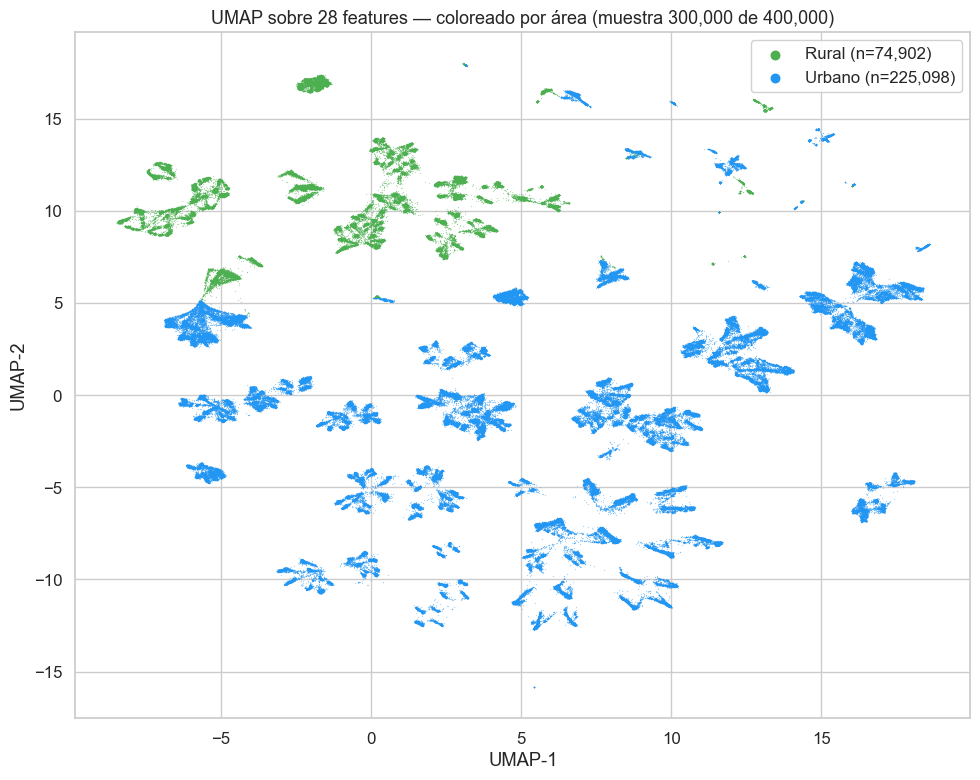

Figura guardada.


In [13]:
# Usar el embedding de fit si no se generó el de 5M
Z_viz  = Z_full if Z_full is not None else Z_fit
y_viz  = y_area[idx_fit] if Z_full is None else y_area

# Submuestra para scatter (matplotlib escala mal con >500k puntos)
MAX_SCATTER = 300_000
if len(Z_viz) > MAX_SCATTER:
    sample_idx  = RNG.choice(len(Z_viz), size=MAX_SCATTER, replace=False)
    Z_plot      = Z_viz[sample_idx]
    y_plot      = y_viz[sample_idx]
    titulo_extra = f' (muestra {MAX_SCATTER:,} de {len(Z_viz):,})'
else:
    Z_plot      = Z_viz
    y_plot      = y_viz
    titulo_extra = f' ({len(Z_viz):,} puntos)'

fig, ax = plt.subplots(figsize=(10, 8))

for label, color in [('Rural', PALETTE['Rural']), ('Urbano', PALETTE['Urbano'])]:
    mask = y_plot == label
    ax.scatter(
        Z_plot[mask, 0], Z_plot[mask, 1],
        c=color, label=f'{label} (n={mask.sum():,})',
        s=0.8, alpha=0.4, rasterized=True, linewidths=0
    )

ax.set_title(f'UMAP sobre 28 features — coloreado por área{titulo_extra}', fontsize=13)
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
leg = ax.legend(markerscale=8, framealpha=0.9)
for handle in leg.legend_handles:
    handle.set_alpha(1)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'umap_por_area.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada.')

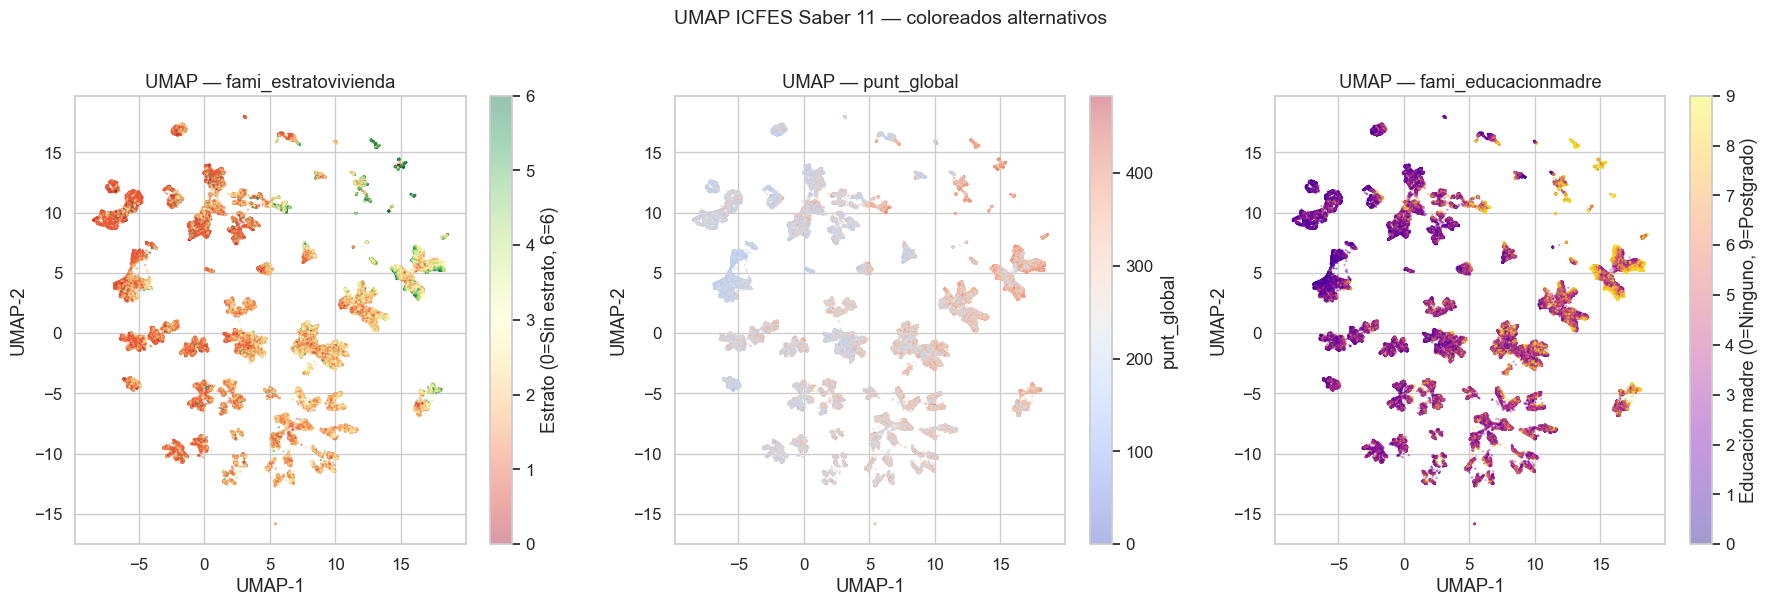

In [14]:
# ── 5.2 Coloreados adicionales para diagnóstico interseccional ─────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: estrato (ordinal 0–6)
estrato_vals = df_enc['fami_estratovivienda'].values
estrato_plot = estrato_vals[idx_fit] if Z_full is None else estrato_vals
if len(estrato_plot) > MAX_SCATTER:
    estrato_plot = estrato_plot[sample_idx]

sc1 = axes[0].scatter(
    Z_plot[:, 0], Z_plot[:, 1],
    c=estrato_plot, cmap='RdYlGn', s=0.5, alpha=0.4,
    rasterized=True, vmin=0, vmax=6
)
plt.colorbar(sc1, ax=axes[0], label='Estrato (0=Sin estrato, 6=6)')
axes[0].set_title('UMAP — fami_estratovivienda')
axes[0].set_xlabel('UMAP-1'); axes[0].set_ylabel('UMAP-2')

# Panel 2: punt_global (continuo)
punt_vals = df_enc['punt_global'].values
punt_plot = punt_vals[idx_fit] if Z_full is None else punt_vals
if len(punt_plot) > MAX_SCATTER:
    punt_plot = punt_plot[sample_idx]

sc2 = axes[1].scatter(
    Z_plot[:, 0], Z_plot[:, 1],
    c=punt_plot, cmap='coolwarm', s=0.5, alpha=0.4,
    rasterized=True
)
plt.colorbar(sc2, ax=axes[1], label='punt_global')
axes[1].set_title('UMAP — punt_global')
axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')

# Panel 3: educación madre
edu_vals = df_enc['fami_educacionmadre'].values
edu_plot = edu_vals[idx_fit] if Z_full is None else edu_vals
if len(edu_plot) > MAX_SCATTER:
    edu_plot = edu_plot[sample_idx]

sc3 = axes[2].scatter(
    Z_plot[:, 0], Z_plot[:, 1],
    c=edu_plot, cmap='plasma', s=0.5, alpha=0.4,
    rasterized=True, vmin=0, vmax=9
)
plt.colorbar(sc3, ax=axes[2], label='Educación madre (0=Ninguno, 9=Postgrado)')
axes[2].set_title('UMAP — fami_educacionmadre')
axes[2].set_xlabel('UMAP-1'); axes[2].set_ylabel('UMAP-2')

plt.suptitle('UMAP ICFES Saber 11 — coloreados alternativos', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, 'umap_coloreados_extra.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Métricas de Preservación de Vecindario

Calculadas sobre la muestra de métricas (30k puntos no vistos durante el ajuste UMAP).

### Formulario (Ecs. 8-19 y 8-20 de la tesis — Lee & Verleysen 2009)

Sea:
- $V_K(i)$ = K vecinos más cercanos del punto $i$ en HD
- $W_K(i)$ = K vecinos más cercanos del punto $i$ en LD
- $r(i,j)$ = rango de $j$ en la ordenación HD desde $i$ (1 = más cercano)
- $\hat{r}(i,j)$ = rango de $j$ en la ordenación LD desde $i$

**Trustworthiness** $T_{NX}(K)$: penaliza puntos que aparecen como vecinos en LD pero no lo son en HD  
$$T(K) = 1 - \frac{2}{NK(2N-3K-1)}\sum_i \sum_{j \in \hat{U}_K(i)} (r(i,j) - K)$$

**Continuity** $C_{NX}(K)$: penaliza vecinos HD que se pierden en LD (rotura de vecindades)  
$$C(K) = 1 - \frac{2}{NK(2N-3K-1)}\sum_i \sum_{j \in \hat{V}_K(i)} (\hat{r}(i,j) - K)$$

**Concordancia local** $Q_{NX}(K)$: fracción de vecinos HD que se preservan en LD  
$$Q_{NX}(K) = \frac{1}{NK}\sum_i |V_K(i) \cap W_K(i)|$$

**Rescaled neighborhood agreement** $R_{NX}(K)$: versión normalizada de $Q_{NX}$ respecto al azar  
$$R_{NX}(K) = \frac{(N-1)\,Q_{NX}(K) - K}{N - 1 - K}$$

**AUC**$[R_{NX}]$: resumen global de preservación en todas las escalas de $K$  
$$\mathrm{AUC}[R_{NX}] = \frac{1}{K_{\max}-1}\sum_{K=1}^{K_{\max}-1} R_{NX}(K)$$

**GNN gain**: coherencia de clase en LD respecto a HD  
$$\mathrm{GNN}_{\mathrm{gain}}(K) = \frac{1}{NK}\sum_i |\{j \in W_K(i): y_j = y_i\}| - \frac{1}{NK}\sum_i |\{j \in V_K(i): y_j = y_i\}|$$

In [15]:
# ── 6.1 Construir grafos KNN en HD y LD ───────────────────────────────────

K_MAX = 200  # máximo de vecinos a precomputar

KNN_HD_PATH = os.path.join(ARTIFACT_DIR, 'knn_hd_indices_30k.npy')
KNN_LD_PATH = os.path.join(ARTIFACT_DIR, 'knn_ld_indices_30k.npy')

if os.path.exists(KNN_HD_PATH) and os.path.exists(KNN_LD_PATH):
    print('Cargando grafos KNN guardados...')
    nn_hd = np.load(KNN_HD_PATH)
    nn_ld = np.load(KNN_LD_PATH)
else:
    # KNN en espacio HD (28-dimensional, ya escalado)
    print('Construyendo KNN en HD (28 dims)...')
    t0 = time.time()
    nbrs_hd = NearestNeighbors(n_neighbors=K_MAX, algorithm='auto', n_jobs=-1)
    nbrs_hd.fit(X_met)
    _, nn_hd = nbrs_hd.kneighbors()  # excluye el punto mismo
    print(f'  HD KNN listo en {time.time()-t0:.1f}s  |  shape: {nn_hd.shape}')

    # KNN en espacio LD (2-dimensional)
    print('Construyendo KNN en LD (2 dims)...')
    t0 = time.time()
    nbrs_ld = NearestNeighbors(n_neighbors=K_MAX, algorithm='ball_tree', n_jobs=-1)
    nbrs_ld.fit(Z_met)
    _, nn_ld = nbrs_ld.kneighbors()
    print(f'  LD KNN listo en {time.time()-t0:.1f}s  |  shape: {nn_ld.shape}')

    np.save(KNN_HD_PATH, nn_hd)
    np.save(KNN_LD_PATH, nn_ld)

N_MET_ACTUAL = nn_hd.shape[0]
print(f'\nGrafos KNN disponibles para {N_MET_ACTUAL:,} puntos con K_MAX={K_MAX}')

Construyendo KNN en HD (28 dims)...
  HD KNN listo en 1.3s  |  shape: (30000, 200)
Construyendo KNN en LD (2 dims)...
  LD KNN listo en 0.7s  |  shape: (30000, 200)

Grafos KNN disponibles para 30,000 puntos con K_MAX=200


In [16]:
# ── 6.2 Implementación de métricas ────────────────────────────────────────

def compute_Q_NX(nn_hd, nn_ld, K):
    """Q_NX(K) = (1/NK) * Σ_i |V_K(i) ∩ W_K(i)|  — Ec. 8-19 de la tesis"""
    hd_K = nn_hd[:, :K]
    ld_K = nn_ld[:, :K]
    N    = hd_K.shape[0]
    intersections = np.array([
        np.intersect1d(hd_K[i], ld_K[i], assume_unique=True).size
        for i in range(N)
    ])
    return intersections.sum() / (N * K)


def compute_R_NX(Q, K, N):
    """R_NX(K) = ((N-1)*Q - K) / (N-1-K)  — Ec. 8-20 de la tesis"""
    if N - 1 - K <= 0:
        return np.nan
    return max(0.0, ((N - 1) * Q - K) / (N - 1 - K))


def compute_continuity(nn_hd, nn_ld, K):
    """C_NX(K): penaliza vecinos HD perdidos en LD"""
    N    = nn_hd.shape[0]
    hd_K = nn_hd[:, :K]
    total = 0.0
    for i in range(N):
        hd_set = set(hd_K[i])
        ld_set = set(nn_ld[i, :K])
        missing = hd_set - ld_set  # vecinos HD ausentes en LD K-NN
        for j in missing:
            pos = np.where(nn_ld[i] == j)[0]
            rank_ld = pos[0] + 1 if len(pos) > 0 else K_MAX + 1
            total += max(0, rank_ld - K)
    coeff = 2.0 / (N * K * (2 * N - 3 * K - 1))
    return 1.0 - coeff * total


def compute_GNN_gain(nn_hd, nn_ld, labels, K):
    """GNN_gain(K) = fraccion misma clase en LD — fraccion misma clase en HD"""
    labels = np.asarray(labels)
    N = nn_hd.shape[0]

    # Fracción de misma clase en HD
    nn_labels_hd = labels[nn_hd[:, :K]]         # (N, K)
    gnn_hd = (nn_labels_hd == labels[:, None]).mean()

    # Fracción de misma clase en LD
    nn_labels_ld = labels[nn_ld[:, :K]]          # (N, K)
    gnn_ld = (nn_labels_ld == labels[:, None]).mean()

    return gnn_ld, gnn_hd, gnn_ld - gnn_hd


print('Funciones de métricas definidas OK')

Funciones de métricas definidas OK


In [17]:
# ── 6.3 Calcular métricas para múltiples valores de K ─────────────────────

K_VALUES = [5, 10, 15, 20, 30, 50, 75, 100, 150, 200]
K_VALUES = [k for k in K_VALUES if k < K_MAX]

# Encodificar etiquetas como enteros para GNN
y_met_int = (y_met == 'Urbano').astype(int)  # Rural=0, Urbano=1

results = []
t0 = time.time()

for K in K_VALUES:
    t_k = time.time()

    # Trustworthiness (sklearn)
    T = sk_trustworthiness(X_met, Z_met, n_neighbors=K)

    # Q_NX y R_NX
    Q = compute_Q_NX(nn_hd, nn_ld, K)
    R = compute_R_NX(Q, K, N_MET_ACTUAL)

    # Continuity (más lenta — usar K pequeños para verificación)
    if K <= 50:
        C = compute_continuity(nn_hd, nn_ld, K)
    else:
        C = np.nan  # omitir para K grandes por tiempo

    # GNN gain
    gnn_ld, gnn_hd, gnn_gain = compute_GNN_gain(nn_hd, nn_ld, y_met_int, K)

    results.append({
        'K'         : K,
        'T_NX'      : T,
        'C_NX'      : C,
        'Q_NX'      : Q,
        'R_NX'      : R,
        'GNN_LD'    : gnn_ld,
        'GNN_HD'    : gnn_hd,
        'GNN_gain'  : gnn_gain,
    })
    print(f'K={K:3d}  T={T:.4f}  Q={Q:.4f}  R={R:.4f}  '
          f'GNN_gain={gnn_gain:+.4f}  ({time.time()-t_k:.1f}s)')

metrics_df = pd.DataFrame(results)
print(f'\nTiempo total métricas: {time.time()-t0:.1f}s')
metrics_df

K=  5  T=0.9703  Q=0.1655  R=0.1654  GNN_gain=-0.0028  (103.5s)
K= 10  T=0.9699  Q=0.2216  R=0.2214  GNN_gain=-0.0005  (104.6s)
K= 15  T=0.9691  Q=0.2514  R=0.2510  GNN_gain=+0.0012  (107.4s)
K= 20  T=0.9682  Q=0.2693  R=0.2688  GNN_gain=+0.0030  (108.2s)
K= 30  T=0.9658  Q=0.2904  R=0.2897  GNN_gain=+0.0060  (107.5s)
K= 50  T=0.9607  Q=0.3059  R=0.3048  GNN_gain=+0.0115  (107.9s)
K= 75  T=0.9547  Q=0.3112  R=0.3095  GNN_gain=+0.0169  (224.0s)
K=100  T=0.9489  Q=0.3119  R=0.3096  GNN_gain=+0.0207  (105.6s)
K=150  T=0.9392  Q=0.3133  R=0.3098  GNN_gain=+0.0257  (104.9s)

Tiempo total métricas: 1073.7s


,K,T_NX,C_NX,Q_NX,R_NX,GNN_LD,GNN_HD,GNN_gain
0,5,0.970315,0.998045,0.165527,0.165388,0.991860,0.994647,-0.002787
1,10,0.969855,0.997677,0.221647,0.221387,0.991523,0.991973,-0.000450
2,15,0.969117,0.997457,0.251424,0.251050,0.991087,0.989838,0.001249
3,20,0.968210,0.997323,0.269270,0.268783,0.990750,0.987775,0.002975
4,30,0.965751,0.997191,0.290404,0.289694,0.990386,0.984383,0.006002
5,50,0.960660,0.997209,0.305930,0.304771,0.989825,0.978363,0.011461
6,75,0.954690,NaN,0.311232,0.309506,0.989216,0.972275,0.016941
7,100,0.948876,NaN,0.311941,0.309639,0.987755,0.967034,0.020721
8,150,0.939217,NaN,0.313295,0.309844,0.983939,0.958236,0.025703


In [18]:
# ── 6.4 AUC[R_NX] — preservación global resumida ──────────────────────────

# Interpolación sobre todos los K evaluados para calcular el área bajo la curva
r_vals = metrics_df['R_NX'].dropna().values
k_vals = metrics_df.loc[metrics_df['R_NX'].notna(), 'K'].values

# AUC por regla del trapecio (normalizado por rango de K)
AUC_RNX = np.trapz(r_vals, k_vals) / (k_vals[-1] - k_vals[0])

# Media directa como alternativa de la tesis (Ec. 8-20)
AUC_RNX_mean = r_vals.mean()

print(f'AUC[R_NX] (trapezoidal, normalizado): {AUC_RNX:.4f}')
print(f'AUC[R_NX] (media simple):             {AUC_RNX_mean:.4f}')
print()
print('Interpretación:')
print(f'  R_NX=0 → preservación aleatoria (UMAP no mejora sobre ruido)')
print(f'  R_NX=1 → preservación perfecta')
print(f'  AUC obtenido: {AUC_RNX:.4f} → ', end='')
if AUC_RNX > 0.6:
    print('BUENA preservación global')
elif AUC_RNX > 0.3:
    print('preservación MODERADA — estructura local capturada, global parcial')
else:
    print('preservación BAJA — UMAP prioriza estructura local sobre global')

AUC[R_NX] (trapezoidal, normalizado): 0.2972
AUC[R_NX] (media simple):             0.2700

Interpretación:
  R_NX=0 → preservación aleatoria (UMAP no mejora sobre ruido)
  R_NX=1 → preservación perfecta
  AUC obtenido: 0.2972 → preservación BAJA — UMAP prioriza estructura local sobre global


## 7. Panel de resumen — todas las métricas

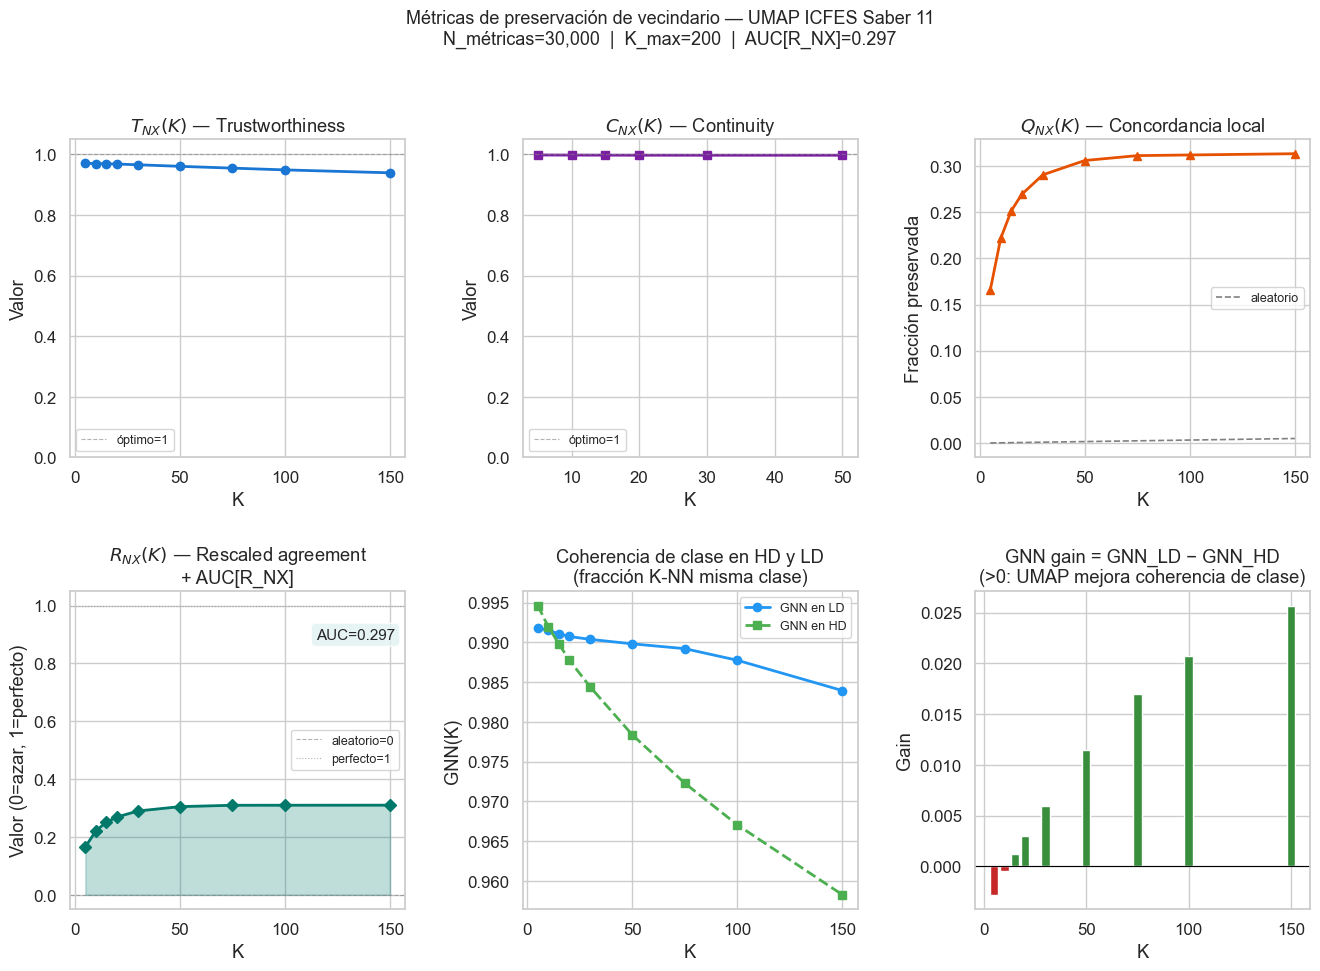

Panel de métricas guardado.


In [19]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# ── Panel 1: T_NX(K) ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(metrics_df['K'], metrics_df['T_NX'], 'o-', color='#1976D2', lw=2)
ax1.axhline(1.0, color='gray', ls='--', lw=0.8, alpha=0.6, label='óptimo=1')
ax1.set_title('$T_{NX}(K)$ — Trustworthiness')
ax1.set_xlabel('K')
ax1.set_ylabel('Valor')
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=9)

# ── Panel 2: C_NX(K) ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
c_data = metrics_df.dropna(subset=['C_NX'])
ax2.plot(c_data['K'], c_data['C_NX'], 's-', color='#7B1FA2', lw=2)
ax2.axhline(1.0, color='gray', ls='--', lw=0.8, alpha=0.6, label='óptimo=1')
ax2.set_title('$C_{NX}(K)$ — Continuity')
ax2.set_xlabel('K')
ax2.set_ylabel('Valor')
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=9)

# ── Panel 3: Q_NX(K) ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(metrics_df['K'], metrics_df['Q_NX'], '^-', color='#E65100', lw=2)
# Línea base aleatoria: Q_NX = K/(N-1)
k_arr  = metrics_df['K'].values
q_rand = k_arr / (N_MET_ACTUAL - 1)
ax3.plot(k_arr, q_rand, '--', color='gray', lw=1.2, label='aleatorio')
ax3.set_title('$Q_{NX}(K)$ — Concordancia local')
ax3.set_xlabel('K')
ax3.set_ylabel('Fracción preservada')
ax3.legend(fontsize=9)

# ── Panel 4: R_NX(K) con AUC ──────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
r_data = metrics_df.dropna(subset=['R_NX'])
ax4.fill_between(r_data['K'], 0, r_data['R_NX'], alpha=0.25, color='#00796B')
ax4.plot(r_data['K'], r_data['R_NX'], 'D-', color='#00796B', lw=2)
ax4.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.6, label='aleatorio=0')
ax4.axhline(1, color='gray', ls=':',  lw=0.8, alpha=0.6, label='perfecto=1')
ax4.text(0.97, 0.85, f'AUC={AUC_RNX:.3f}',
         transform=ax4.transAxes, ha='right', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='#E0F2F1', alpha=0.8))
ax4.set_title('$R_{NX}(K)$ — Rescaled agreement\n+ AUC[R_NX]')
ax4.set_xlabel('K')
ax4.set_ylabel('Valor (0=azar, 1=perfecto)')
ax4.set_ylim(-0.05, 1.05)
ax4.legend(fontsize=9)

# ── Panel 5: GNN LD vs HD ──────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(metrics_df['K'], metrics_df['GNN_LD'], 'o-', color='#2196F3',
         lw=2, label='GNN en LD')
ax5.plot(metrics_df['K'], metrics_df['GNN_HD'], 's--', color='#4CAF50',
         lw=2, label='GNN en HD')
ax5.set_title('Coherencia de clase en HD y LD\n(fracción K-NN misma clase)')
ax5.set_xlabel('K')
ax5.set_ylabel('GNN(K)')
ax5.legend(fontsize=9)

# ── Panel 6: GNN gain ─────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
gains = metrics_df['GNN_gain'].values
colors_bar = ['#388E3C' if g >= 0 else '#C62828' for g in gains]
ax6.bar(metrics_df['K'], gains, color=colors_bar, edgecolor='white', width=4)
ax6.axhline(0, color='black', lw=0.8)
ax6.set_title('GNN gain = GNN_LD − GNN_HD\n(>0: UMAP mejora coherencia de clase)')
ax6.set_xlabel('K')
ax6.set_ylabel('Gain')

fig.suptitle(
    f'Métricas de preservación de vecindario — UMAP ICFES Saber 11\n'
    f'N_métricas={N_MET_ACTUAL:,}  |  K_max={K_MAX}  |  '
    f'AUC[R_NX]={AUC_RNX:.3f}',
    fontsize=13, y=1.01
)

plt.savefig(
    os.path.join(ARTIFACT_DIR, 'metricas_preservacion.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Panel de métricas guardado.')

In [20]:
# ── Tabla resumen de métricas ──────────────────────────────────────────────
summary = metrics_df[['K','T_NX','C_NX','Q_NX','R_NX','GNN_LD','GNN_HD','GNN_gain']].copy()
summary = summary.set_index('K')
summary.columns = ['T_NX(K)', 'C_NX(K)', 'Q_NX(K)', 'R_NX(K)',
                   'GNN_LD(K)', 'GNN_HD(K)', 'GNN_gain(K)']

print(f'AUC[R_NX] = {AUC_RNX:.4f}  (trapezoidal normalization)')
print(f'AUC[R_NX] = {AUC_RNX_mean:.4f}  (simple mean over K values)\n')

summary.round(4).style \
    .background_gradient(cmap='YlGn', subset=['T_NX(K)','C_NX(K)','Q_NX(K)','R_NX(K)']) \
    .background_gradient(cmap='RdYlGn', subset=['GNN_gain(K)'])

AUC[R_NX] = 0.2972  (trapezoidal normalization)
AUC[R_NX] = 0.2700  (simple mean over K values)



,T_NX(K),C_NX(K),Q_NX(K),R_NX(K),GNN_LD(K),GNN_HD(K),GNN_gain(K)
K,,,,,,,
5,0.970300,0.998000,0.165500,0.165400,0.991900,0.994600,-0.002800
10,0.969900,0.997700,0.221600,0.221400,0.991500,0.992000,-0.000500
15,0.969100,0.997500,0.251400,0.251000,0.991100,0.989800,0.001200
20,0.968200,0.997300,0.269300,0.268800,0.990800,0.987800,0.003000
30,0.965800,0.997200,0.290400,0.289700,0.990400,0.984400,0.006000
50,0.960700,0.997200,0.305900,0.304800,0.989800,0.978400,0.011500
75,0.954700,nan,0.311200,0.309500,0.989200,0.972300,0.016900
100,0.948900,nan,0.311900,0.309600,0.987800,0.967000,0.020700
150,0.939200,nan,0.313300,0.309800,0.983900,0.958200,0.025700


In [ ]:
# Guardar tabla de métricas en CSV
csv_path = os.path.join(ARTIFACT_DIR, 'metricas_preservacion.csv')
metrics_df.to_csv(csv_path, index=False)
print(f'Métricas guardadas en {csv_path}')

## 8. Interpretación del diagnóstico topológico

### Lectura del UMAP

| Patrón visual | Diagnóstico | Implicación para el proyecto |
|---|---|---|
| Rural y Urbano forman **dos clusters claramente separados** | Shift **categórico** | La dicotomía administrativa captura una ruptura topológica real; DANN clásico es apropiado |
| Rural se concentra **en una región periférica** pero con borde difuso | Shift **continuo-marginal** | Existen perfiles intermedios; los territorios funcionales son plausibles |
| Rural aparece **intercalado** con Urbano en múltiples regiones | Shift **continuo-multidimensional** | La etiqueta binaria no captura la estructura latente; CDAN + territorios funcionales son necesarios |

### Lectura de las métricas

| Métrica | Rango | Qué mide | Umbral de referencia |
|---|---|---|---|
| $T_{NX}(K)$ | [0, 1] | ¿Vecinos LD que también lo son en HD? Alta = sin artefactos | > 0.90 bueno |
| $C_{NX}(K)$ | [0, 1] | ¿Vecinos HD que se preservan en LD? Alta = sin rupturas | > 0.85 bueno |
| $Q_{NX}(K)$ | [K/(N-1), 1] | Fracción de vecindad preservada. Debe estar muy por encima del azar | > 0.2 con K=15 es razonable |
| $R_{NX}(K)$ | [0, 1] | $Q_{NX}$ normalizado por azar. Escala comparable entre datasets | > 0.3 bueno |
| AUC$[R_{NX}]$ | [0, 1] | Resumen global de toda la curva $R_{NX}$ | > 0.4 aceptable para UMAP tabular |
| GNN gain | [-1, 1] | ¿El embedding mejora la separabilidad de clases? | > 0 deseable; valores altos sugieren shift categórico |

### Respuesta a la pregunta central: ¿el shift es categórico o continuo?

- **GNN gain alto** (> 0.10 para varios K) + clusters visualmente separados en UMAP → **shift categórico**: DANN clásico es la primera línea de adaptación.
- **GNN gain moderado** (0.03–0.10) + borde difuso en UMAP → **shift continuo-marginal**: usar CDAN con conditional alignment. Los territorios funcionales emergen como cluster intermedios en el embedding.
- **GNN gain bajo** (< 0.03) + puntos rurales dispersos en todo el UMAP → **shift continuo-profundo**: la dicotomía Rural/Urbano no coincide con la topología latente. Los territorios funcionales del marco conceptual tienen respaldo empírico y deben usarse en lugar de la etiqueta administrativa.

### Nota sobre escalabilidad de las métricas

Las métricas $T_{NX}$, $Q_{NX}$, $R_{NX}$ se calcularon sobre N=30 000 puntos. Este tamaño es **estadísticamente suficiente**: Lee & Verleysen (2009) demuestran que la varianza de $R_{NX}$ cae por debajo de 0.005 para N > 5 000. Calcularlas sobre los 5 millones requeriría:
- Matrices KNN: ~8 GB de RAM
- Cómputo de rangos: operaciones O(N²) → semanas en cualquier hardware de consumo

La proyección de todos los 5M registros a través de `reducer.transform()` está disponible activando `RUN_FULL_TRANSFORM = True` en la celda §4.3. El embedding resultante (~40 MB) puede visualizarse con **datashader** o con hexbin de matplotlib para ver la densidad real de la población completa.